<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/hysteresis_Nanoparticle_Temperature_vs_Time_LRT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#USE ONLY THE UNITS SPECIFIED IN THE COMMENTS AFTER EACH VALUE IN THIS CELL

Ms = 446e3            # [A/m]
K = 41e3               # [J/m^3]
Cp = 670                # [J/(kg K)]
rho = 5180              # [kg/m^3]

kB = 1.380649e-23        # [J/K]
mu0 = 4 * np.pi * 1e-7   # [H/m]
tau0 = 1e-9              # [s]

==================================================================
 Nanoparticle Temperature vs Time (Magnetic Hyperthermia, LRT)
==================================================================

Validity check: LRT applies when xi = (mu0 * Ms * V_H * H0) / (kB * T) <= 1
Safety imit H0F <= 1.51 * 10^8 A m-1 s-1

HOW IT WORKS
------------
Fixed inputs: viscosity (eta), frequency (f), core radius (R),
              shell thickness (delta)

Field: H(t) amplitude is defined as a function of time

Procedure:
  1. Set initial temperature T_initial
  2. Loop over each time step (n_steps = t_total / dt):
       - compute H(t)
       - compute relaxation times (tau_B, tau_N, tau_eff)
       - compute chi0 and chi'' (out-of-phase susceptibility)
       - compute power dissipation P
       - compute heating rate and update temperature
       - store H(t), heating rate, temperature, and xi
  3. Stop if xi >= 1 (outside the linear response regime)


In [ ]:
# ================================================================
# ================================================================
eta   = 0.0015        # [Pa s]
f     = 300e3         # [Hz]
delta = 1e-9          # [m]
R     = 6.8e-9          # [m]

Cs = 3700                # [J/(kg K)] specific heat capacity of sample
ms    =  3.48507e-20 # [kg] density * volume sphere(R)
mNP =  8.0987e-21 # [kg] 1 particle

omega = 2 * np.pi * f
VM = (4.0 / 3.0) * np.pi * R ** 3
VH = (4.0 / 3.0) * np.pi * (R + delta) ** 3

# ================================================================
#  H_A(t) : amplitude ของสนาม เป็นฟังก์ชันของเวลา
# ================================================================
H_max = 6.3e-3      # [T] ค่าช่วงแรก (ที่ราบสูง)
H_min = 0e-3    # [T] ค่าหลังดิ่งลง (ที่ราบต่ำ)
t0    = 55.0      # [s] จุดกึ่งกลางที่ดิ่งลง
w     = 10.0       # [s] ความชัน (เล็ก = ดิ่งชันขึ้น)

H_of_t = lambda t: H_min + (H_max - H_min) / (1 + np.exp((t - t0) / w))


In [ ]:
T_initial = 309.0     # [K]
t_total   = 200       # [s]  เวลารวม

cyc_per_step = 100 + 1 / np.pi     # จำนวนรอบสนามต่อ 1 สเต็ป (ห้ามเป็นจำนวนเต็ม)
dt           = cyc_per_step / f    # [s]
n_steps      = int(t_total / dt)

time_array  = np.zeros(n_steps + 1)
Temp_array  = np.zeros(n_steps + 1)
P_array     = np.zeros(n_steps + 1)
xi_array    = np.zeros(n_steps + 1)
H_array     = np.zeros(n_steps + 1)   # amplitude H0 [T]
Hinst_array = np.zeros(n_steps + 1)   # H(t)    [A/m]  <-- สนามจริง
Minst_array = np.zeros(n_steps + 1)   # M(H(t)) [A/m]  <-- คำนวณจาก H(t)

Temp_array[0]  = T_initial
H_array[0]     = H_of_t(0.0)
Hinst_array[0] = H_of_t(0.0) / mu0
xi_array[0]    = (mu0 * Ms * VM * H_of_t(0.0) / mu0) / (kB * T_initial)

tem_i  = T_initial
last_i = n_steps
# ================================================================
#  LOOP
# ================================================================
for i in range(1, n_steps + 1):

    t   = i * dt
    H_T = H_of_t(t)          # amplitude [Tesla] ณ เวลา t
    H_A = H_T / mu0          # Tesla -> A/m

    # ---- relaxation times ----
    gamma   = (K * VM) / (kB * tem_i)
    tau_b   = (3 * eta * VH) / (kB * tem_i)
    tau_n   = (tau0 / 2) * np.exp(gamma)
    tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))

    # ---- susceptibility & power ----
    chi0 = (mu0 * Ms ** 2 * VM) / (3 * kB * tem_i)
    chi_prime       = chi0 / (1 + (omega * tau_eff) ** 2)               # in-phase
    chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)
    P = mu0 * H_A ** 2 * f * np.pi * chi_doubleprime

    # ---- update temperature ----
    tem_i = tem_i + ((P*mNP) / (rho * Cs*ms)) * dt

    # ---- H(t) และ M(H(t))  ----
    wt  = omega * t
    c   = np.cos(wt)
    s   = np.sin(wt)
    H_i = H_A * c                                  # H(t)  = H0 cos(wt)
    M_i = H_A * (chi_prime * c + chi_doubleprime * s)   # M(t)

    # ---- เก็บผลลัพธ์ ----
    time_array[i]  = t
    Temp_array[i]  = tem_i
    P_array[i]     = P
    H_array[i]     = H_T
    Hinst_array[i] = H_i
    Minst_array[i] = M_i

    # ---- ตรวจเงื่อนไข LRT (xi << 1) ----
    xi = (mu0 * Ms * VM * H_A) / (kB * tem_i)
    xi_array[i] = xi
    if xi >= 1:
        print(f"ไม่ได้: xi = {xi:.3f} >= 1 ที่ t = {t:.2f} s")
        print(f"อุณหภูมิล่าสุด = {tem_i:.4f} K")
        last_i = i
        break

In [ ]:
gamma_init   = (K * VM) / (kB * T_initial)
tau_b_init   = (3 * eta * VH) / (kB * T_initial)
tau_n_init   = (tau0 / 2) * np.exp(gamma_init)
tau_eff_init = 1 / ((1 / tau_b_init) + (1 / tau_n_init))

print("=== Relaxation Times at T_initial ===")
print(f"Brownian relaxation time (tau_b): {tau_b_init:.4e} s ({tau_b_init * 1e6:.4f} µs)")
print(f"Néel relaxation time (tau_n): {tau_n_init:.4e} s")
print(f"Effective relaxation time (tau_eff): {tau_eff_init:.4e} s ({tau_eff_init * 1e6:.4f} µs)")
print(f"omega * tau_eff: {omega * tau_eff_init:.4f}")

=== Relaxation Times at T_initial ===
Brownian relaxation time (tau_b): 2.0967e-06 s (2.0967 µs)
Néel relaxation time (tau_n): 1.5710e-04 s
Effective relaxation time (tau_eff): 2.0691e-06 s (2.0691 µs)
omega * tau_eff: 3.9002


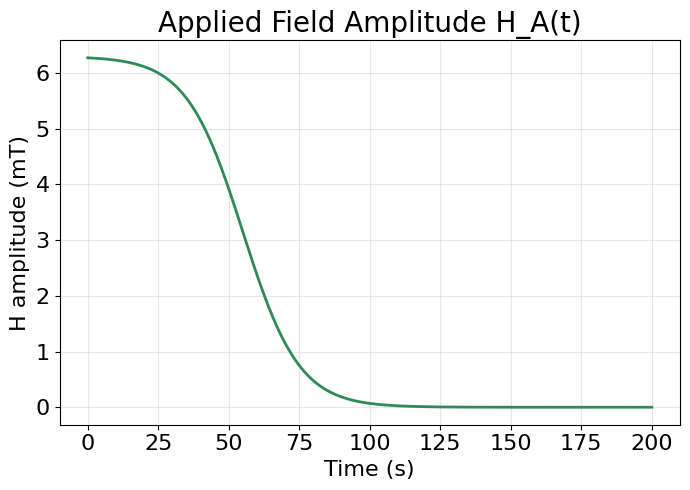

In [ ]:
# ================================================================
#  PLOT
# ================================================================
sl = slice(None)
# ---- H(t) ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], H_array[sl] * 1e3, color='seagreen', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('H amplitude (mT)', fontsize=16)
plt.title('Applied Field Amplitude H_A(t)', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

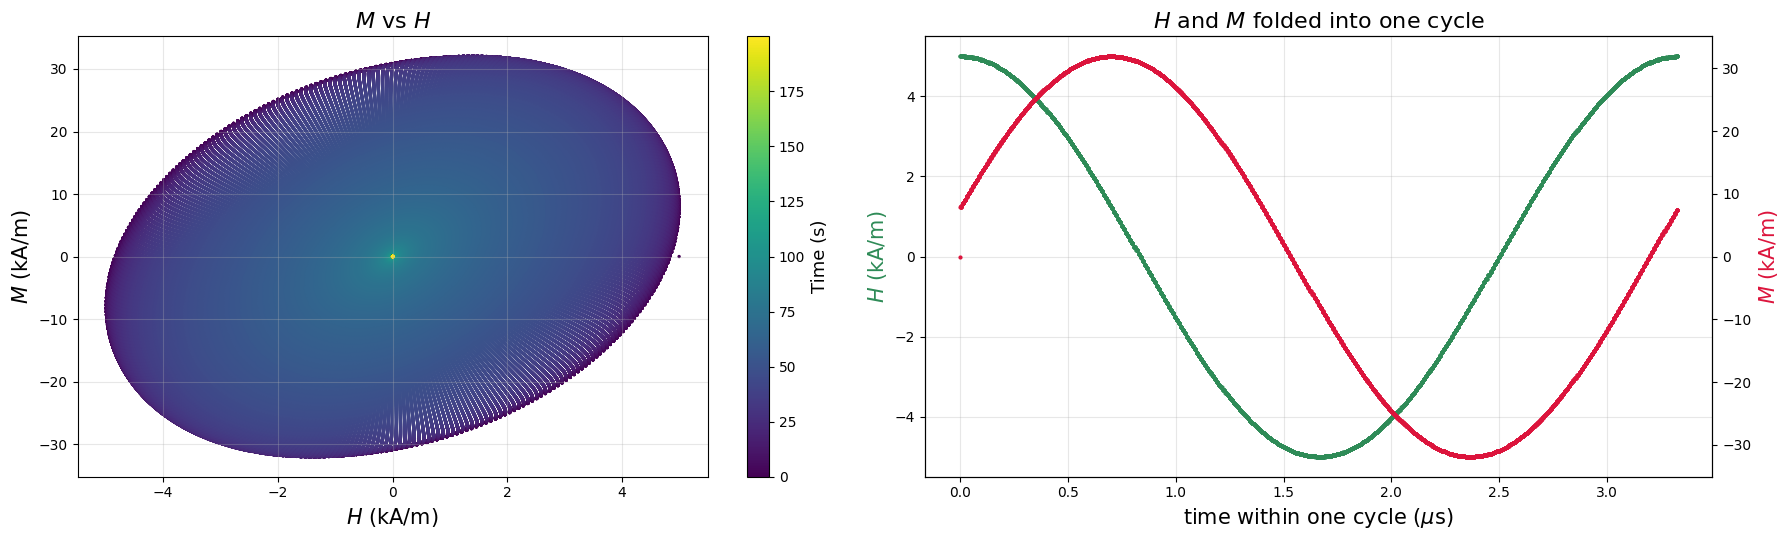

In [ ]:
# ================================================================
#  PLOT hysteresis H / M
# ================================================================
sl  = slice(0, last_i + 1)
t_p = time_array[sl]
H_p = Hinst_array[sl] / 1e3      # kA/m
M_p = Minst_array[sl] / 1e3      # kA/m

t_center, half = 0.0, 1.0                  #WINDOW HERE
mk = np.abs(t_p - t_center) <= half

fig, ax = plt.subplots(1, 2, figsize=(18, 5.5))

sc = ax[0].scatter(H_p, M_p, c=t_p, cmap='viridis', s=2)
cb = fig.colorbar(sc, ax=ax[0]); cb.set_label('Time (s)', fontsize=13)
ax[0].set_xlabel('$H$ (kA/m)', fontsize=15)
ax[0].set_ylabel('$M$ (kA/m)', fontsize=15)
ax[0].set_title('$M$ vs $H$', fontsize=16)
ax[0].grid(True, alpha=0.3)

tph = np.mod(omega * t_p[mk], 2 * np.pi) / omega * 1e6
ax[1].plot(tph, H_p[mk], '.', ms=4, color='seagreen')
a1 = ax[1].twinx()
a1.plot(tph, M_p[mk], '.', ms=4, color='crimson')
ax[1].set_xlabel('time within one cycle ($\\mu$s)', fontsize=15)
ax[1].set_ylabel('$H$ (kA/m)', fontsize=15, color='seagreen')
a1.set_ylabel('$M$ (kA/m)', fontsize=15, color='crimson')
ax[1].set_title('$H$ and $M$ folded into one cycle', fontsize=16)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

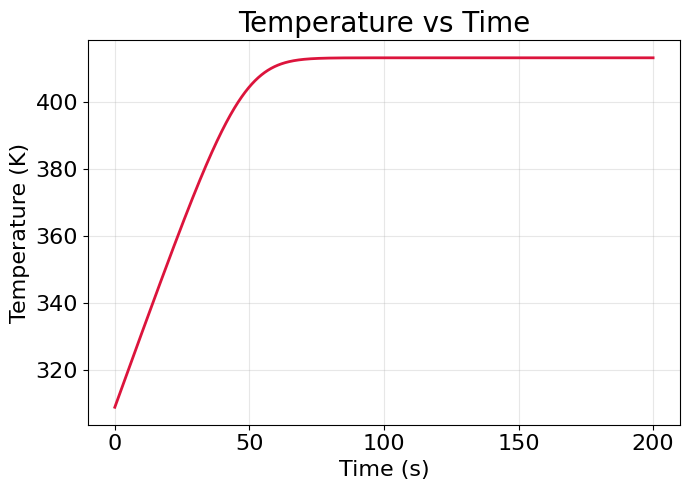

อุณหภูมิสุดท้ายที่ t = 200.00 s: 413.0586 K


In [ ]:
# ---- Temperature vs Time ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], Temp_array[sl], color='crimson', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Temperature (K)', fontsize=16)
plt.title('Temperature vs Time', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()
print(f"อุณหภูมิสุดท้ายที่ t = {time_array[last_i]:.2f} s: {Temp_array[last_i]:.4f} K")

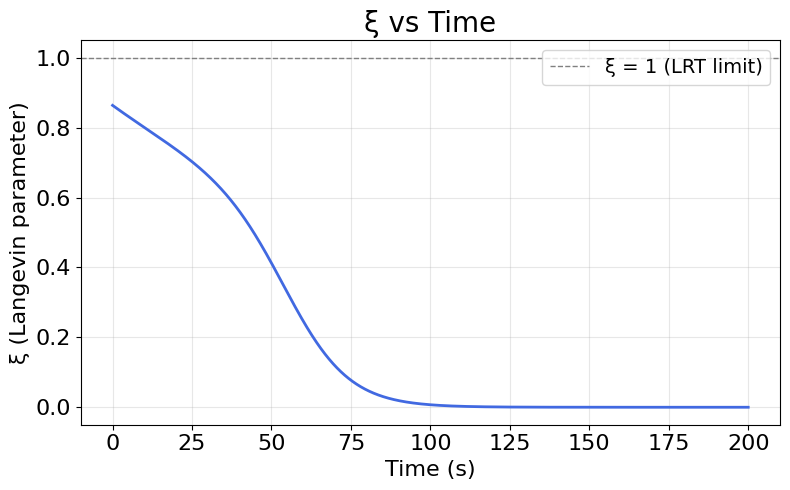

In [ ]:
# ---- xi vs Time ----
plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], xi_array[sl], color='royalblue', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='ξ = 1 (LRT limit)')
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('ξ (Langevin parameter)', fontsize=16)
plt.title('ξ vs Time', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

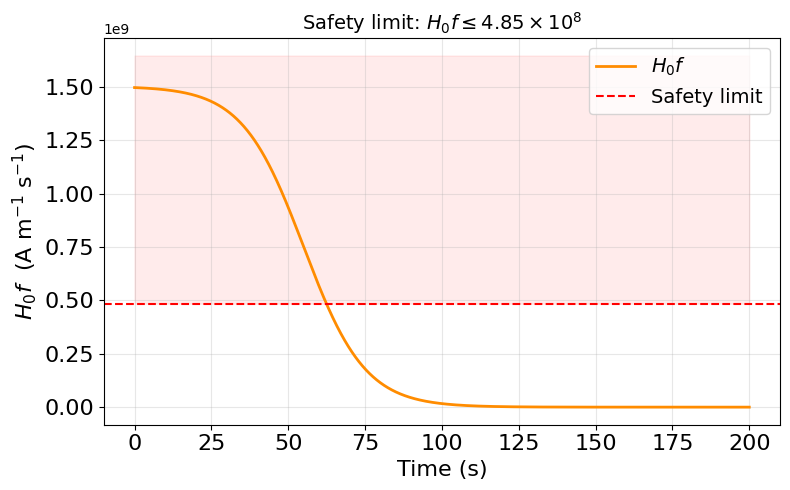

In [ ]:
# ================================================================
#  ---- H0*f safety limit (Atkinson-Brezovich) vs Time ----
# ================================================================
Hf_limit = 4.85e8                 # [A/(m s)]  ขีดจำกัดความปลอดภัย

sl = slice(0, last_i + 1)         # ตัดช่วงที่ยังไม่ได้คำนวณทิ้ง (เผื่อ loop break)

H0_array = H_array / mu0          # [A/m]       amplitude ในหน่วย A/m
Hf_array = H0_array * f           # [A/(m s)]   ผลคูณ H0*f

plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], Hf_array[sl], color='darkorange', linewidth=2, label='$H_0 f$')
plt.axhline(y=Hf_limit, color='red', linestyle='--', linewidth=1.5, label='Safety limit')
plt.fill_between(time_array[sl], Hf_limit, max(Hf_array[sl].max(), Hf_limit) * 1.10,
                 color='red', alpha=0.08)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('$H_0 f$  (A m$^{-1}$ s$^{-1}$)', fontsize=16)
plt.title('Safety limit: $H_0 f \\leq 4.85\\times10^{8}$', fontsize=14)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

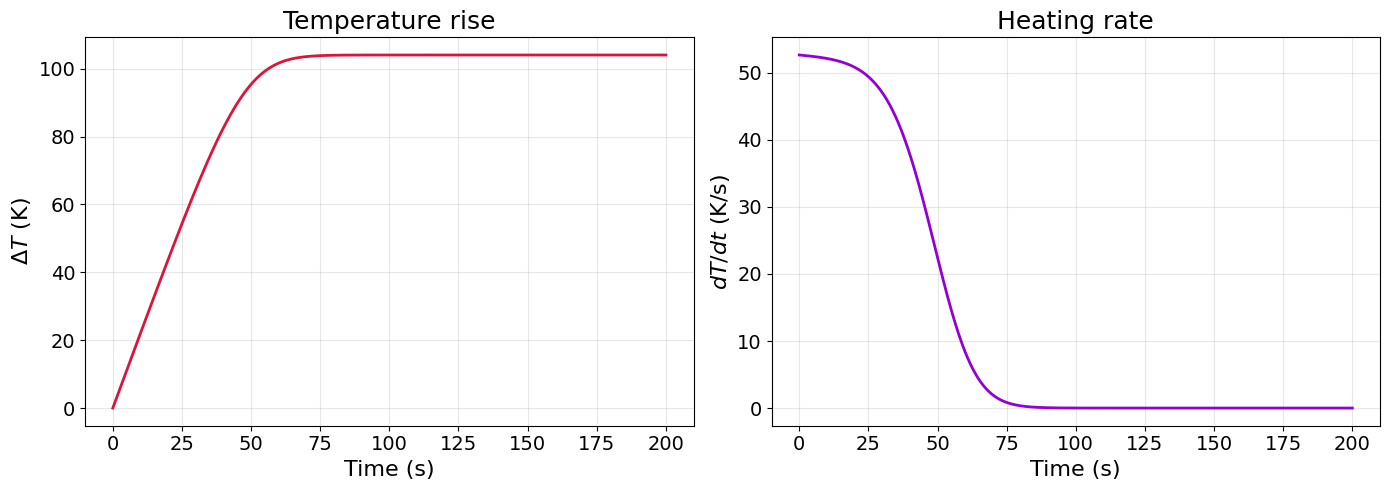

  t [s]      T [K]     dT [K]      P [W/m3]   dT/dt [K/s]   SAR [W/kg]  H0f/limit        xi
    0.0   309.0000     0.0000    0.0000e+00    0.0000e+00   0.0000e+00      3.088    0.8639
   10.0   331.0578    22.0578    1.8092e+08    5.2130e+01   3.4927e+04      3.067    0.8008
   20.0   352.7676    43.7676    1.7640e+08    5.0826e+01   3.4053e+04      3.010    0.7376
   30.0   373.4940    64.4940    1.6330e+08    4.7052e+01   3.1525e+04      2.866    0.6632
   40.0   391.5954    82.5954    1.3128e+08    3.7826e+01   2.5344e+04      2.535    0.5596
   50.0   404.4141    95.4141    7.7893e+07    2.2444e+01   1.5037e+04      1.930    0.4126
   60.0   410.6702   101.6702    2.9014e+07    8.3601e+00   5.6013e+03      1.171    0.2464
   70.0   412.5879   103.5879    6.8008e+06    1.9596e+00   1.3129e+03      0.566    0.1185
   80.0   412.9834   103.9834    1.1770e+06    3.3913e-01   2.2722e+02      0.235    0.0492
   90.0   413.0477   104.0477    1.7576e+05    5.0642e-02   3.3930e+01      0.09

In [ ]:
# ================================================================
#  ---- Heating vs Time ----
# ================================================================
dT_array   = Temp_array - T_initial     # [K]      อุณหภูมิที่เพิ่มขึ้น
rate_array = P_array / (rho * Cp)       # [K/s]    อัตราการให้ความร้อน
SAR_array  = P_array / rho              # [W/kg]   specific absorption rate [W/m^3] / [kg/m^3] = [W/kg]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(time_array[sl], dT_array[sl], color='crimson', linewidth=2)
ax[0].set_xlabel('Time (s)', fontsize=16)
ax[0].set_ylabel('$\\Delta T$ (K)', fontsize=16)
ax[0].set_title('Temperature rise', fontsize=18)
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis='both', labelsize=14)

sl1 = slice(1, last_i + 1)
ax[1].plot(time_array[sl1], rate_array[sl1], color='darkviolet', linewidth=2)
ax[1].set_xlabel('Time (s)', fontsize=16)
ax[1].set_ylabel('$dT/dt$ (K/s)', fontsize=16)
ax[1].set_title('Heating rate', fontsize=18)
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

print(f"{'t [s]':>7} {'T [K]':>10} {'dT [K]':>10} {'P [W/m3]':>13}"
      f" {'dT/dt [K/s]':>13} {'SAR [W/kg]':>12} {'H0f/limit':>10} {'xi':>9}")
for t_mark in np.arange(0.0, time_array[last_i] + 1e-9, 10.0 ):
    j = int(round(t_mark / dt))
    if j > last_i:
        break
    print(f"{time_array[j]:7.1f} {Temp_array[j]:10.4f} {dT_array[j]:10.4f}"
          f" {P_array[j]:13.4e} {rate_array[j]:13.4e} {SAR_array[j]:12.4e}"
          f" {Hf_array[j]/Hf_limit:10.3f} {xi_array[j]:9.4f}")

print(f"\nΔT รวม = {dT_array[last_i]:.4f} K")
print(f"อัตราสูงสุด = {rate_array[sl].max():.4e} K/s,  SAR สูงสุด = {SAR_array[sl].max():.4e} W/kg")